# Speech Emotion Recognition — Log-Mel + ResNet34 Pipeline

Transfer-learning approach: fine-tune a **ResNet34** pretrained on ImageNet  
following the same protocol as DeepEmoNet (Vu, 2025).


In [18]:
import os
import re
import random

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from prettytable import PrettyTable

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import resnet34, ResNet34_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# ── Paths ──────────────────────────────────────────────────────────────────
RAVDESS_PATH = "../../../data/ravdess"
SAVEE_PATH   = "../../../data/savee"

# ── Emotion mappings ───────────────────────────────────────────────────────
emotion_to_label = {
    "neutral": 0, "calm": 1, "happy": 2, "sad": 3,
    "angry": 4, "fear": 5, "disgust": 6, "surprise": 7
}
ravdess_code_to_emotion = {
    "01": "neutral", "02": "calm",    "03": "happy",
    "04": "sad",     "05": "angry",   "06": "fear",
    "07": "disgust", "08": "surprise"
}
savee_code_to_emotion = {
    "a": "angry", "d": "disgust", "f": "fear",
    "h": "happy", "n": "neutral", "sa": "sad", "su": "surprise"
}

# ── Feature params ─────────────────────────────────────────────────────────
SAMPLE_RATE = 16000
N_MELS      = 128
N_FFT       = 1024
HOP_LENGTH  = 512
IMG_SIZE    = 128   # spectrogram resized to IMG_SIZE × IMG_SIZE

# ── Training params (DeepEmoNet protocol) ─────────────────────────────────
BATCH_SIZE  = 64
EPOCHS      = 30        
LR          = 1e-3
LR_DECAY    = 0.9       
NUM_CLASSES = len(emotion_to_label)
MIXUP_ALPHA = 0.3       

# ── ImageNet normalisation stats ──────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Epochs : {EPOCHS}  |  LR={LR}  |  decay={LR_DECAY}/epoch")


Device : cuda
Epochs : 30  |  LR=0.001  |  decay=0.9/epoch


## 1 · Load Metadata (RAVDESS + SAVEE)

In [19]:
records = []
for actor in os.listdir(RAVDESS_PATH):
    for fn in os.listdir(f"{RAVDESS_PATH}/{actor}"):
        if not fn.endswith(".wav"):
            continue
        parts   = fn.replace(".wav", "").split("-")
        emotion = ravdess_code_to_emotion[parts[2]]
        records.append({"path": f"{RAVDESS_PATH}/{actor}/{fn}",
                         "emotion": emotion, "label": emotion_to_label[emotion],
                         "dataset": "RAVDESS"})
ravdess_df = pd.DataFrame(records)
print(f"RAVDESS : {len(ravdess_df)} samples")
print(ravdess_df["emotion"].value_counts())


RAVDESS : 1440 samples
emotion
calm        192
happy       192
sad         192
angry       192
fear        192
disgust     192
surprise    192
neutral      96
Name: count, dtype: int64


In [20]:
records = []
for fn in os.listdir(SAVEE_PATH):
    if not fn.lower().endswith(".wav"):
        continue
    speaker, ep = os.path.splitext(fn)[0].split("_")
    code        = re.match(r"[a-z]+", ep).group()  # type: ignore
    emotion     = savee_code_to_emotion[code]
    records.append({"path": f"{SAVEE_PATH}/{fn}",
                     "emotion": emotion, "label": emotion_to_label[emotion],
                     "dataset": "SAVEE"})
savee_df = pd.DataFrame(records).sort_values("path").reset_index(drop=True)
print(f"SAVEE   : {len(savee_df)} samples")
print(savee_df["emotion"].value_counts())


SAVEE   : 480 samples
emotion
neutral     120
angry        60
disgust      60
fear         60
happy        60
sad          60
surprise     60
Name: count, dtype: int64


Combined: (1920, 4)


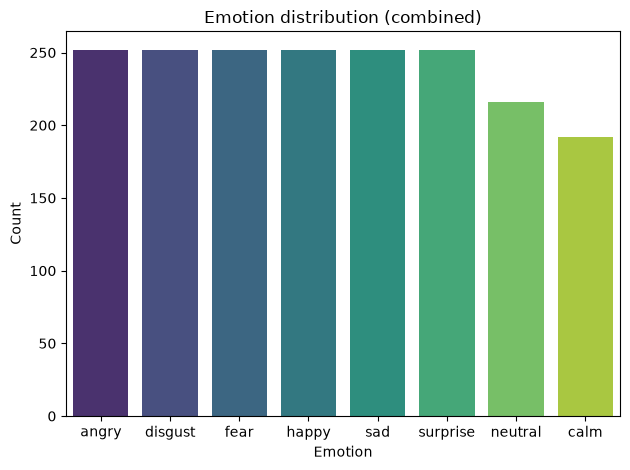

In [21]:
combined_df = pd.concat([savee_df, ravdess_df], ignore_index=True)
print(f"Combined: {combined_df.shape}")
os.makedirs("CSVs", exist_ok=True)
combined_df.to_csv("CSVs/combined_metadata.csv", index=False)

counts = combined_df["emotion"].value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette="viridis", legend=False)
plt.title("Emotion distribution (combined)")
plt.xlabel("Emotion"); plt.ylabel("Count")
plt.tight_layout(); plt.show()


## 2 · Feature Extraction Helpers

Log-mel spectrogram → normalised to `[0, 1]` → 3-channel image (repeat grayscale)  
so it matches the shape expected by ImageNet-pretrained backbones.


In [22]:
def extract_logmelspec(path, sample_rate=SAMPLE_RATE,
                        n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Load audio → log-mel spectrogram (T, N_MELS) in dB."""
    audio, sr = librosa.load(path, sr=sample_rate)
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
    )
    return librosa.power_to_db(mel, ref=np.max)  # (N_MELS, T)


def pad_or_trim(spec, max_steps=IMG_SIZE):
    """Pad or trim the time axis so spec has exactly max_steps frames."""
    T = spec.shape[1]
    if T >= max_steps:
        return spec[:, :max_steps]
    return np.pad(spec, ((0, 0), (0, max_steps - T)), mode="constant")


def spec_to_tensor(spec):
    """(N_MELS, T) → (3, N_MELS, T) normalised float32 tensor.

    Normalise log-dB [-80, 0] → [0, 1], then repeat channel 3× to
    match RGB input expected by ImageNet pretrained models.
    """
    img = (spec - spec.min()) / (spec.max() - spec.min() + 1e-6)
    img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # (1, H, W)
    return img.repeat(3, 1, 1)                                  # (3, H, W)


## 3 · Extract Log-Mel Spectrograms

In [23]:
spec_list, label_list = [], []
for _, row in tqdm(combined_df.iterrows(), total=len(combined_df),
                   desc="Extracting"):
    spec = pad_or_trim(extract_logmelspec(row["path"]))
    spec_list.append(spec)
    label_list.append(row["label"])

labels = np.array(label_list)
print(f"\n✓ {len(spec_list)} samples  |  shape: {spec_list[0].shape}")


Extracting: 100%|██████████| 1920/1920 [00:30<00:00, 62.41it/s] 


✓ 1920 samples  |  shape: (128, 128)


## 4 · Train / Val / Test Split  (80 / 10 / 10)

In [24]:
X_tv, X_test, y_tv, y_test = train_test_split(
    spec_list, labels, test_size=0.1, random_state=42, stratify=labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.111, random_state=42, stratify=y_tv
)
print(f"Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")


Train: 1536  |  Val: 192  |  Test: 192


## 5 · Dataset with Image-based Augmentation

Augmentation mirrors the DeepEmoNet protocol (rotate, zoom, brightness/contrast).  
Applied **only** to the training split.


In [25]:
def get_transforms(augment: bool, img_size: int = IMG_SIZE):
    """Return torchvision transform pipeline.

    Both train and eval pipelines resize + normalise with ImageNet stats.
    The train pipeline additionally applies random spatial / colour jitter.
    """
    base = [
        T.Resize((img_size, img_size)),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    if augment:
        aug = [
            T.RandomHorizontalFlip(),
            T.RandomAffine(degrees=10, scale=(0.9, 1.1)),   # rotate + zoom
            T.ColorJitter(brightness=0.3, contrast=0.3),    # brightness
        ]
        return T.Compose(aug + base)
    return T.Compose(base)


class SpectrogramDataset(Dataset):
    """Log-mel spectrogram dataset that returns 3-channel image tensors.

    Parameters
    ----------
    spec_list  : list of np.ndarray (N_MELS, T)
    label_list : array-like of int
    transform  : torchvision transform pipeline (from get_transforms)
    """
    def __init__(self, spec_list, label_list, transform=None):
        self.specs     = spec_list
        self.labels    = np.asarray(label_list)
        self.transform = transform

    def __len__(self):
        return len(self.specs)

    def __getitem__(self, idx):
        img = spec_to_tensor(self.specs[idx])   # (3, H, W) float32 [0,1]
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])


train_ds = SpectrogramDataset(X_train, y_train, transform=get_transforms(augment=True))
val_ds   = SpectrogramDataset(X_val,   y_val,   transform=get_transforms(augment=False))
test_ds  = SpectrogramDataset(X_test,  y_test,  transform=get_transforms(augment=False))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print("✓ DataLoaders ready")


✓ DataLoaders ready


## 6 · Mixup Helper

Mixup (Zhang et al., 2018): tạo convex combination của cặp mẫu để regularise.  
Điều chỉnh `MIXUP_ALPHA` trong cell config ở trên (`0` = tắt Mixup).


In [26]:
def mixup_batch(x, y, alpha=MIXUP_ALPHA, num_classes=NUM_CLASSES):
    """Apply Mixup to a mini-batch.

    Returns mixed inputs and soft one-hot target tensors.
    """
    if alpha <= 0:
        y_onehot = torch.zeros(y.size(0), num_classes, device=y.device)
        y_onehot.scatter_(1, y.unsqueeze(1), 1.0)
        return x, y_onehot

    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1 - lam) * x[idx]

    y_onehot = torch.zeros(y.size(0), num_classes, device=y.device)
    y_onehot.scatter_(1, y.unsqueeze(1), 1.0)
    y_mix = lam * y_onehot + (1 - lam) * y_onehot[idx]
    return x_mix, y_mix


## 7 · Model — ResNet34 (pretrained on ImageNet)

Load pretrained weights, then replace the final fully-connected layer  
with a new `Linear(512 → NUM_CLASSES)` head trained from scratch.


In [27]:
# Load ResNet34 with ImageNet pretrained weights
model = resnet34(weights=ResNet34_Weights.DEFAULT)

# Replace the final FC layer: 512 → NUM_CLASSES
model.fc = nn.Sequential( # type: ignore
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)

model = model.to(device)

total   = sum(p.numel() for p in model.parameters())
print(f"✓ ResNet34 (pretrained=ImageNet)  |  {total/1e6:.1f}M parameters")
print(f"  Final head: Linear(512 → {NUM_CLASSES})")


✓ ResNet34 (pretrained=ImageNet)  |  21.3M parameters
  Final head: Linear(512 → 8)


## 8 · Training Loop Helpers

Two reusable functions: `train_epoch` and `eval_epoch`.  
Both return `(loss, accuracy, f1)`.


In [28]:
def soft_cross_entropy(logits, soft_targets):
    """Cross-entropy that accepts soft (Mixup) labels."""
    log_probs = torch.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()


def train_epoch(model, loader, optimizer, device, alpha=MIXUP_ALPHA):
    """Run one training epoch with optional Mixup.

    Returns
    -------
    avg_loss : float
    acc      : float  (hard-label accuracy on mixed batch)
    f1       : float  (macro F1)
    """
    model.train()
    total_loss, preds_all, targets_all = 0.0, [], []

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        X_mix, y_soft = mixup_batch(X, y, alpha=alpha)

        optimizer.zero_grad()
        logits = model(X_mix)
        loss   = soft_cross_entropy(logits, y_soft)
        loss.backward()
        optimizer.step()

        total_loss  += loss.item() * X.size(0)
        hard_pred    = logits.argmax(1).cpu().numpy()
        hard_target  = y.cpu().numpy()      # original (pre-mix) labels
        preds_all.extend(hard_pred)
        targets_all.extend(hard_target)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(targets_all, preds_all)
    f1  = f1_score(targets_all, preds_all, average="macro", zero_division=0)
    return avg_loss, acc, f1


def eval_epoch(model, loader, device):
    """Evaluate model on a DataLoader (no augmentation, no Mixup).

    Returns
    -------
    avg_loss : float
    acc      : float
    f1       : float  (macro F1)
    preds    : list[int]
    targets  : list[int]
    """
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, preds_all, targets_all = 0.0, [], []

    with torch.no_grad():
        for X, y in loader:
            X, y  = X.to(device), y.to(device)
            logits = model(X)
            total_loss += criterion(logits, y).item() * X.size(0)
            preds_all.extend(logits.argmax(1).cpu().numpy())
            targets_all.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(targets_all, preds_all)
    f1  = f1_score(targets_all, preds_all, average="macro", zero_division=0)
    return avg_loss, acc, f1, preds_all, targets_all


## 9 · Fine-tune

**Optimiser**: Adam, lr=1e-3  
**LR schedule**: ExponentialLR, γ=0.9/epoch  
**Loss**: Cross-Entropy (soft labels via Mixup during training)  
**Epochs**: 30 (DeepEmoNet protocol for pretrained ResNet34)


In [29]:
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=LR_DECAY)

history = {k: [] for k in
           ["train_loss", "train_acc", "train_f1",
            "val_loss",   "val_acc",   "val_f1",  "lr"]}

best_val_loss   = float("inf")
best_model_path = "best_cnn_model.pth"

for epoch in tqdm(range(EPOCHS), desc="Epochs"):
    current_lr = optimizer.param_groups[0]["lr"]

    t_loss, t_acc, t_f1 = train_epoch(model, train_loader, optimizer, device)
    v_loss, v_acc, v_f1, _, _ = eval_epoch(model, val_loader, device) # type: ignore
    scheduler.step()

    for k, v in [("train_loss", t_loss), ("train_acc", t_acc), ("train_f1", t_f1),
                 ("val_loss",   v_loss), ("val_acc",   v_acc), ("val_f1",   v_f1),
                 ("lr",         current_lr)]:
        history[k].append(v)

    checkpoint_mark = ""
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), best_model_path)
        checkpoint_mark = "  ★"

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}]  lr={current_lr:.2e}  "
          f"train loss={t_loss:.4f} acc={t_acc*100:.1f}% f1={t_f1:.4f}  |  "
          f"val loss={v_loss:.4f} acc={v_acc*100:.1f}% f1={v_f1:.4f}{checkpoint_mark}")

model.load_state_dict(torch.load(best_model_path))
print("\n✓ Best checkpoint restored.")


Epochs:   3%|▎         | 1/30 [00:07<03:24,  7.04s/it]

Epoch [01/30]  lr=1.00e-03  train loss=2.2385 acc=17.3% f1=0.1766  |  val loss=5.9404 acc=25.5% f1=0.2109  ★


Epochs:   7%|▋         | 2/30 [00:13<03:10,  6.79s/it]

Epoch [02/30]  lr=9.00e-04  train loss=1.9441 acc=20.1% f1=0.2009  |  val loss=2.6194 acc=16.1% f1=0.1121  ★


Epochs:  10%|█         | 3/30 [00:19<02:57,  6.56s/it]

...

Epoch [28/30]  lr=5.81e-05  train loss=0.6346 acc=52.4% f1=0.5246  |  val loss=0.7732 acc=76.0% f1=0.7615


Epochs:  97%|█████████▋| 29/30 [03:03<00:06,  6.11s/it]

Epoch [29/30]  lr=5.23e-05  train loss=0.6481 acc=48.6% f1=0.4849  |  val loss=0.7292 acc=76.6% f1=0.7688


Epochs: 100%|██████████| 30/30 [03:09<00:00,  6.33s/it]

Epoch [30/30]  lr=4.71e-05  train loss=0.6922 acc=53.5% f1=0.5347  |  val loss=0.6652 acc=76.0% f1=0.7594  ★

✓ Best checkpoint restored.


## 10 · Evaluation on Test Set

In [30]:
_, test_acc, test_f1, test_preds, test_targets = eval_epoch(model, test_loader, device)

test_prec   = precision_score(test_targets, test_preds, average="macro", zero_division=0)
test_recall = recall_score(test_targets, test_preds,    average="macro", zero_division=0)

print("Test results (best checkpoint):")
print(f"  Accuracy : {test_acc*100:.2f}%")
print(f"  Precision: {test_prec:.4f}  (macro)")
print(f"  Recall   : {test_recall:.4f}  (macro)")
print(f"  F1-Score : {test_f1:.4f}  (macro)")


Test results (best checkpoint):
  Accuracy : 72.40%
  Precision: 0.7312  (macro)
  Recall   : 0.7332  (macro)
  F1-Score : 0.7299  (macro)


In [31]:
label_names = [k for k, _ in sorted(emotion_to_label.items(), key=lambda x: x[1])]

print("Classification Report (Test Set):")
print(classification_report(test_targets, test_preds,
                             target_names=label_names, zero_division=0))


Classification Report (Test Set):
              precision    recall  f1-score   support

     neutral       0.82      0.82      0.82        22
        calm       0.83      1.00      0.90        19
       happy       0.52      0.56      0.54        25
         sad       0.68      0.60      0.64        25
       angry       0.75      0.72      0.73        25
        fear       0.61      0.68      0.64        25
     disgust       0.77      0.68      0.72        25
    surprise       0.88      0.81      0.84        26

    accuracy                           0.72       192
   macro avg       0.73      0.73      0.73       192
weighted avg       0.73      0.72      0.72       192



## 11 · Confusion Matrix

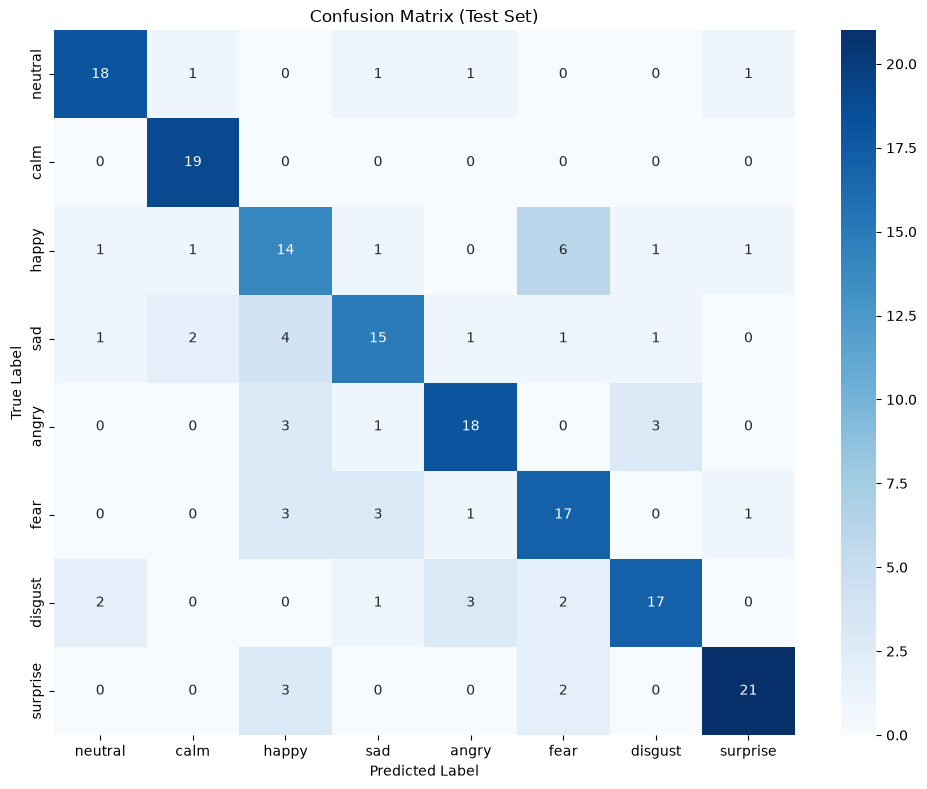

In [32]:
def plot_confusion_matrix(y_true, y_pred, label_names, title, save_dir="result"):
    """Plot and save a normalised confusion matrix heat-map."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f"{save_dir}/{title.replace(' ', '_')}.png", dpi=300)
    plt.show()


plot_confusion_matrix(test_targets, test_preds, label_names, "Confusion Matrix (Test Set)")


## 12 · Training Curves

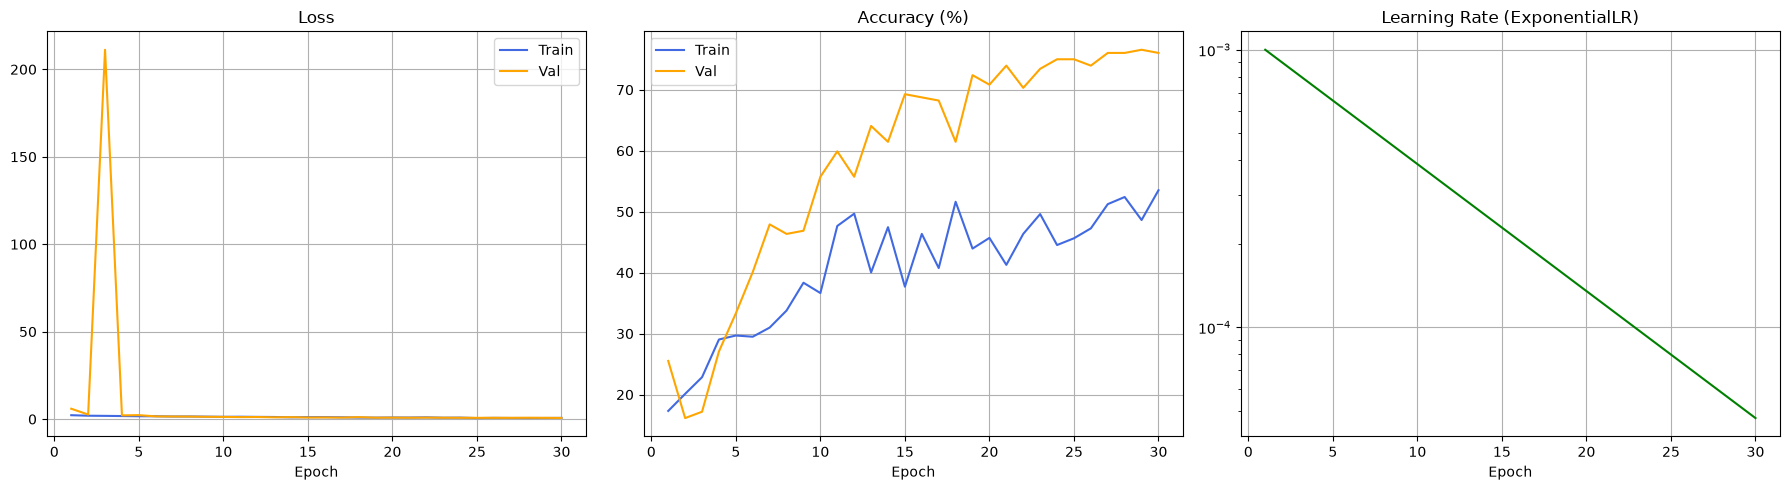

✓ Saved → result/training_curves_resnet34.png


In [33]:
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes    = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train", color="royalblue")
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   color="orange")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, [a*100 for a in history["train_acc"]], label="Train", color="royalblue")
axes[1].plot(epochs_range, [a*100 for a in history["val_acc"]],   label="Val",   color="orange")
axes[1].set_title("Accuracy (%)"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True)

axes[2].plot(epochs_range, history["lr"], color="green")
axes[2].set_title("Learning Rate (ExponentialLR)"); axes[2].set_xlabel("Epoch")
axes[2].set_yscale("log"); axes[2].grid(True)

plt.tight_layout()
os.makedirs("result", exist_ok=True)
plt.savefig("result/training_curves_resnet34.png", dpi=150)
plt.show()
print("✓ Saved → result/training_curves_resnet34.png")


## 13 · Summary

In [34]:
print("ResNet34 (pretrained=ImageNet) — Final Results")
_, tr_acc, tr_f1, tr_preds, tr_targets = eval_epoch(model, train_loader, device)
_, va_acc, va_f1, va_preds, va_targets = eval_epoch(model, val_loader,   device)

table = PrettyTable()
table.field_names = ["Split", "Samples", "Accuracy", "F1 (macro)"]
for split, n, acc, f1 in [
    ("Train",      len(X_train), tr_acc, tr_f1),
    ("Validation", len(X_val),   va_acc, va_f1),
    ("Test",       len(X_test),  test_acc, test_f1),
]:
    table.add_row([split, n, f"{acc:.2%}", f"{f1:.4f}"])
print(table)


ResNet34 (pretrained=ImageNet) — Final Results
+------------+---------+----------+------------+
|   Split    | Samples | Accuracy | F1 (macro) |
+------------+---------+----------+------------+
|   Train    |   1536  |  96.09%  |   0.9607   |
| Validation |   192   |  76.04%  |   0.7594   |
|    Test    |   192   |  72.40%  |   0.7299   |
+------------+---------+----------+------------+
